In [1]:
# Import Libraries
import rawpy as rp
import cv2
import numpy as np
from numpy import asarray
import pandas as pd

import flat_field #custom
import Curvature #custom

import PIL
from PIL import Image
from PIL.ExifTags import TAGS
import exiftool
import notebook

from pathlib import Path 
import glob
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

In [2]:
path = 'Stacking_Database/*.dng'

In [3]:
raw_img = []
for img in glob.glob(path):
    n= rp.imread(img)
    raw_img.append(n)

In [4]:
bayer = []
for i in raw_img:
    bayer.append(i.raw_image)
    
raw_arr = []
for i in bayer:
    raw_arr.append(asarray(i))
    
avg = np.mean(raw_arr, axis=0).astype(int)

In [5]:
def extract_green_planes(bayer_img):
    """
    Extract the two green planes from an RGGB Bayer image.
    Returns (G1, G2) as NumPy arrays.
    """
    # G1: even rows, odd columns
    g1 = bayer_img[0::2, 1::2]

    # G2: odd rows, even columns
    g2 = bayer_img[1::2, 0::2]

    return g1, g2

green1_ave, green2_ave = extract_green_planes(avg)

green_ave = np.rint((green1_ave + green2_ave) / 2).astype(np.int16)

In [6]:
def green_average_from_bayer(bayer_img, out_dtype=np.int16):
    g1, g2 = extract_green_planes(bayer_img)
    return np.rint((g1 + g2) / 2).astype(out_dtype)

# raw_arr is a list (or array) of 5 bayer frames, each (H, W)
green_arr = np.stack([green_average_from_bayer(frame) for frame in raw_arr], axis=0)

In [7]:
w1, w2 = 400, 400
x1, y1, wx1, wy1 = 790, 550, w1, w2

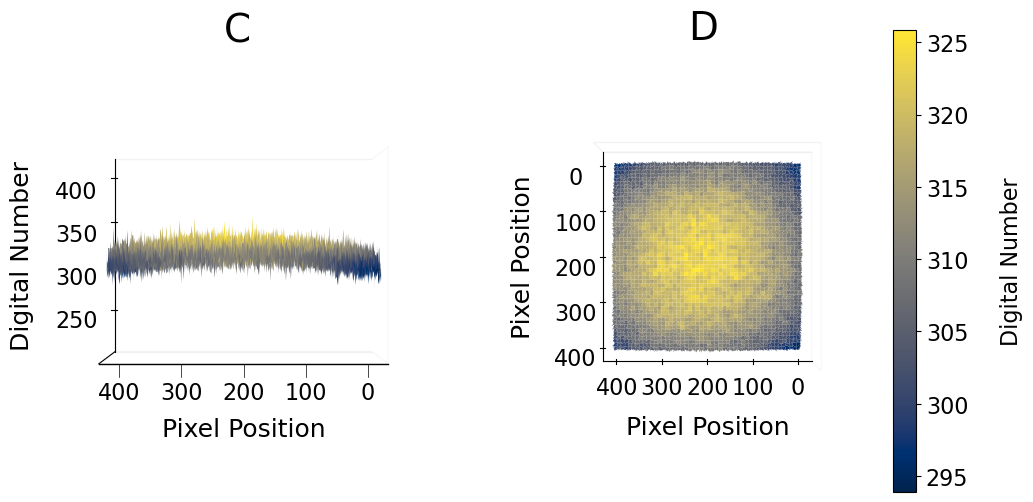

In [8]:
flat_field.flat_field(green_ave[y1:y1+wy1, x1:x1+wx1], 'C', 'D', 'uniformity_stack.png')

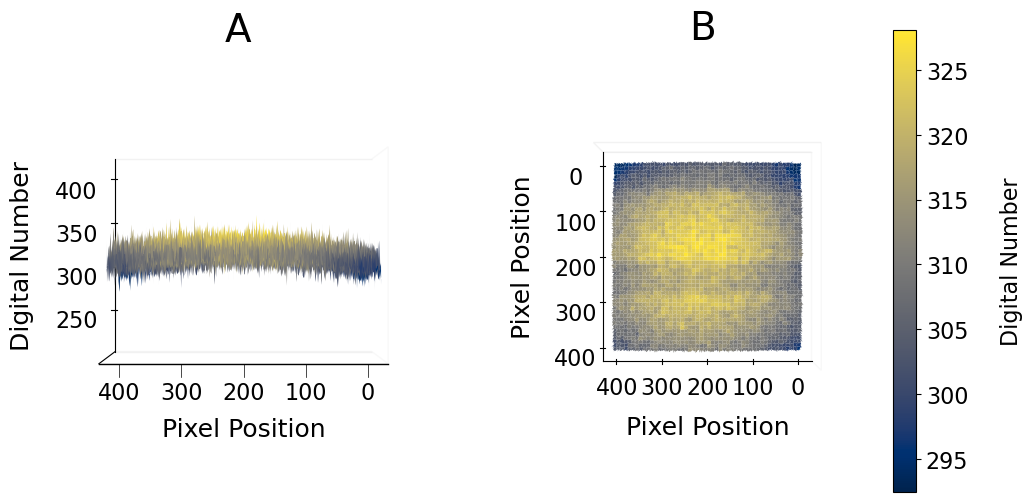

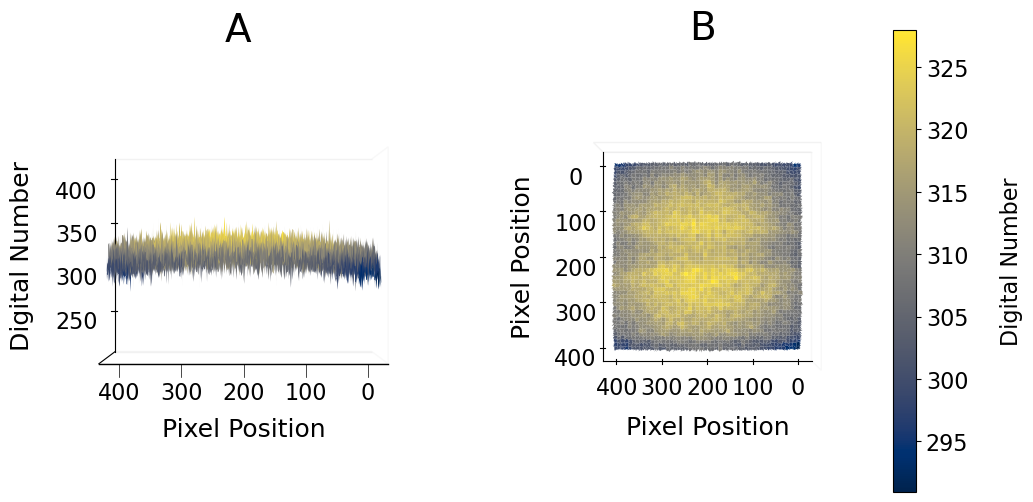

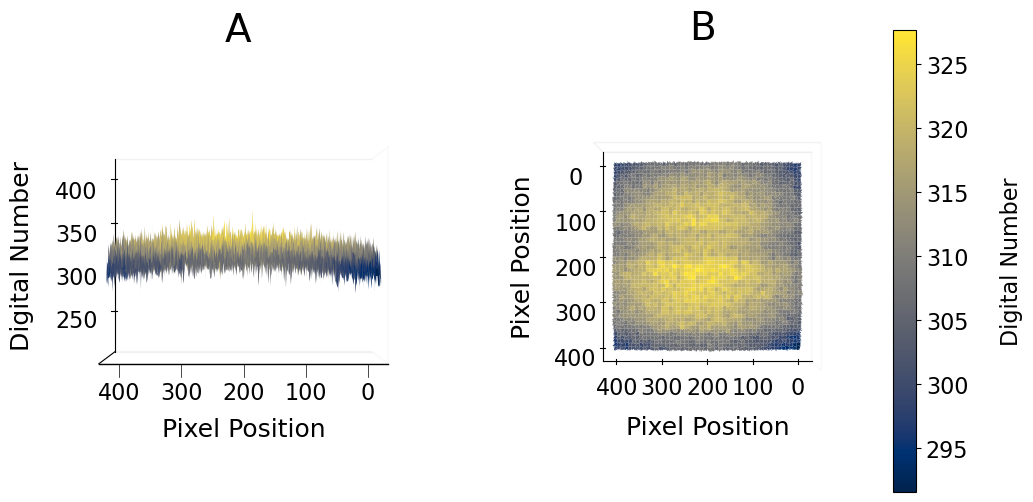

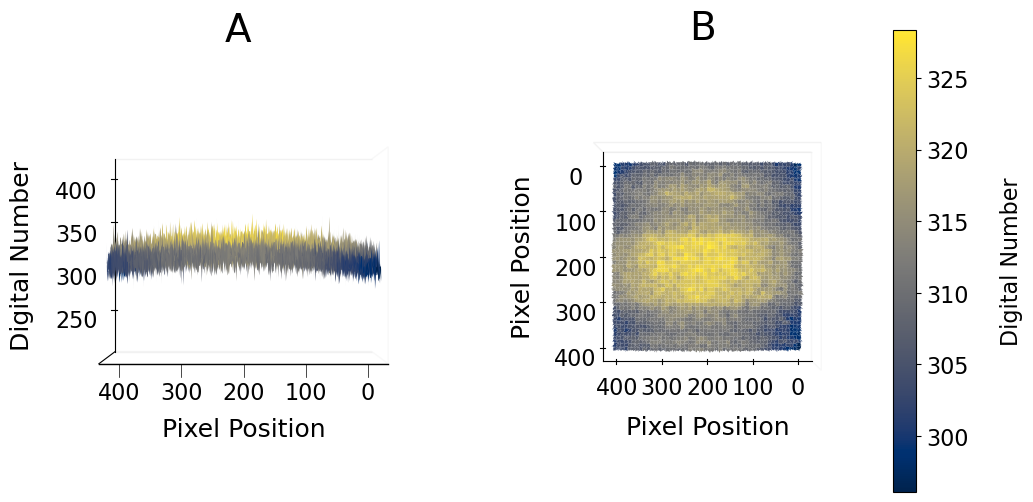

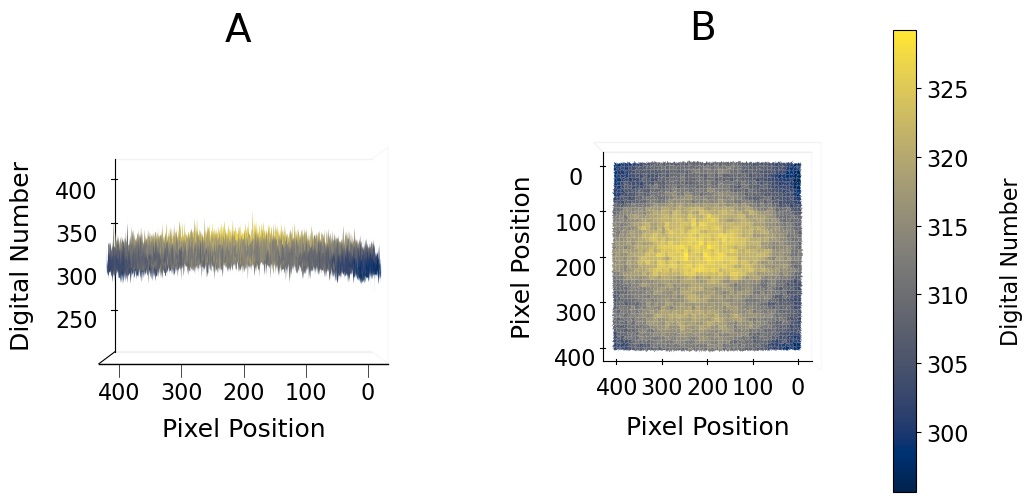

In [9]:
for i, frame in enumerate(green_arr):
    roi = frame[y1:y1+wy1, x1:x1+wx1]
    flat_field.flat_field(
        roi,
        'A',
        'B',
        f'uniformity_stack_individual_{i}.png'
    )


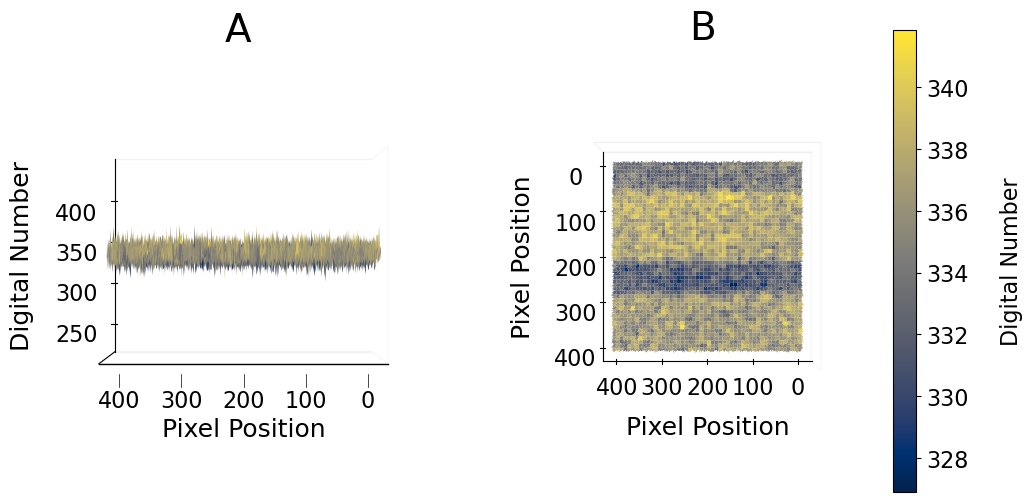

In [10]:
# Quantify Curvature, Banding, and High-Frequency Noise Quantified

H, W = green_arr[0][y1:y1+wy1, x1:x1+wx1].shape
mean_dn = green_arr[0][y1:y1+wy1, x1:x1+wx1].mean()

# --- CURVATURE (2-D low-frequency illumination gradient): quadratic surface fit ---
# z(x,y) = c0 + c1*x + c2*y + c3*x^2 + c4*x*y + c5*y^2

yy, xx = np.mgrid[0:H, 0:W]  # yy: rows, xx: cols

A = np.column_stack([
    np.ones(H * W),
    xx.ravel(),
    yy.ravel(),
    (xx**2).ravel(),
    (xx * yy).ravel(),
    (yy**2).ravel()
])

b = green_arr[0][y1:y1+wy1, x1:x1+wx1].ravel()

coef, *_ = np.linalg.lstsq(A, b, rcond=None)

curv_field = (coef[0]
              + coef[1] * xx + coef[2] * yy
              + coef[3] * xx**2 + coef[4] * xx * yy + coef[5] * yy**2)

# Detrend while preserving overall brightness, then shift for visualization 
resid = green_arr[0][y1:y1+wy1, x1:x1+wx1] - curv_field
im_detrended = (resid - resid.min())+300

# Keep using the existing plotting / flat-field visualization
flat_field.flat_field(im_detrended, 'A', 'B', 'uncurved_single.png')

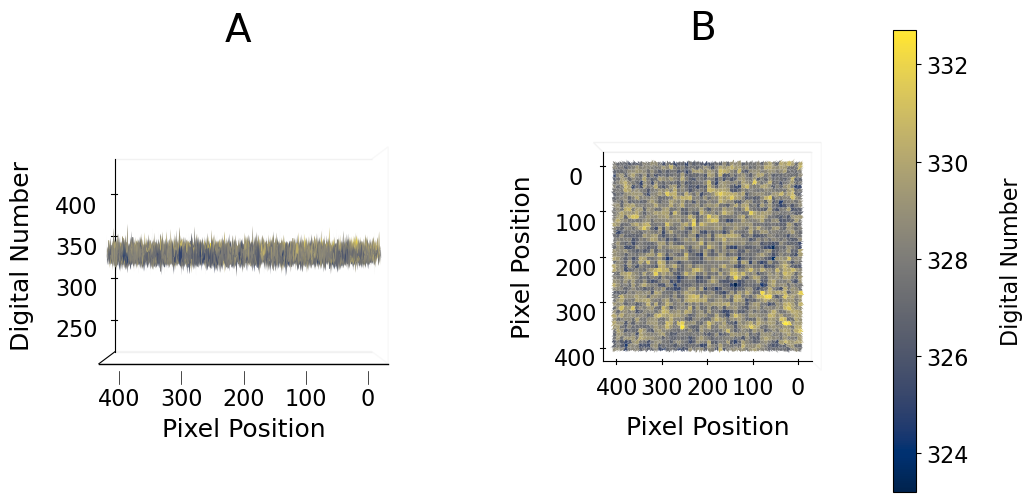

In [11]:
H, W = green_ave[y1:y1+wy1, x1:x1+wx1].shape
mean_dn = green_ave[y1:y1+wy1, x1:x1+wx1].mean()

# --- CURVATURE (2-D low-frequency illumination gradient): quadratic surface fit ---
# z(x,y) = c0 + c1*x + c2*y + c3*x^2 + c4*x*y + c5*y^2

yy, xx = np.mgrid[0:H, 0:W]  # yy: rows, xx: cols

A = np.column_stack([
    np.ones(H * W),
    xx.ravel(),
    yy.ravel(),
    (xx**2).ravel(),
    (xx * yy).ravel(),
    (yy**2).ravel()
])

b = green_ave[y1:y1+wy1, x1:x1+wx1].ravel()

coef, *_ = np.linalg.lstsq(A, b, rcond=None)

curv_field = (coef[0]
              + coef[1] * xx + coef[2] * yy
              + coef[3] * xx**2 + coef[4] * xx * yy + coef[5] * yy**2)

# Detrend while preserving overall brightness, then shift for visualization 
resid = green_ave[y1:y1+wy1, x1:x1+wx1] - curv_field
im_detrended_ave = (resid - resid.min())+300

# Keep using the existing plotting / flat-field visualization
flat_field.flat_field(im_detrended_ave, 'A', 'B', 'uncurved_stacked.png')

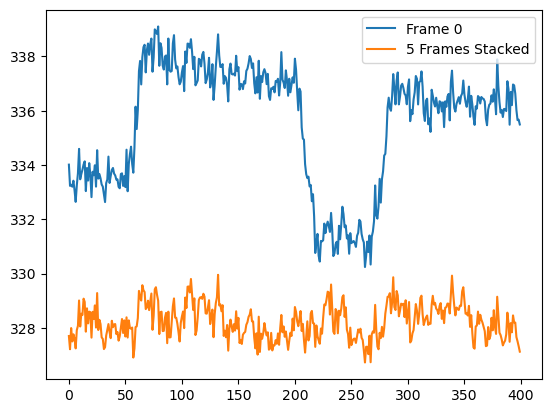

In [12]:
unstack = im_detrended.T.mean(axis=0)
stack = im_detrended_ave.T.mean(axis=0)

# plt.plot((unstack/np.amax(unstack)), label = 'Frame 0')
# plt.plot((stack/np.amax(stack)), label = '5 Frames Stacked')
# plt.ylim(0.9, 1)
# plt.legend()
# plt.show()

plt.plot(unstack, label = 'Frame 0')
plt.plot(stack, label = '5 Frames Stacked')
plt.legend()
plt.show()

In [13]:
np.savetxt('stack_column.csv', stack, delimiter=',', header='profile')
np.savetxt('nostack_column.csv', unstack, delimiter=',', header='profile')

In [14]:
def rms_row_ripple(row_profile):
    """
    Compute RMS banding error from a 1-D row profile.
    
    Parameters
    ----------
    row_profile : array-like
        Mean DN per row (e.g., column-averaged image).
    
    Returns
    -------
    rms : float
        RMS row ripple in DN.
    """
    row_profile = np.asarray(row_profile)
    detrended = row_profile - row_profile.mean()
    rms = np.sqrt(np.mean(detrended**2))
    return rms


In [15]:
rms_stack   = rms_row_ripple(stack)
rms_nostack = rms_row_ripple(unstack)

print(f"RMS banding (stacked):   {rms_stack:.3f} DN")
print(f"RMS banding (no stack):  {rms_nostack:.3f} DN")

RMS banding (stacked):   0.628 DN
RMS banding (no stack):  2.249 DN


In [16]:
def precompute_quadratic_design(H, W):
    yy, xx = np.mgrid[0:H, 0:W]
    A = np.column_stack([
        np.ones(H * W),
        xx.ravel(),
        yy.ravel(),
        (xx**2).ravel(),
        (xx * yy).ravel(),
        (yy**2).ravel()
    ])
    return A, xx, yy

def flatten_frame_quadratic(img2d, A):
    """
    Fit quadratic surface to img2d and subtract it.
    Returns:
      curv_field (2D), resid (2D), flat_preserve_mean (2D)
    """
    H, W = img2d.shape
    b = img2d.astype(np.float64).ravel()
    coef, *_ = np.linalg.lstsq(A, b, rcond=None)

    # Reconstruct fitted field efficiently
    curv_field = (A @ coef).reshape(H, W)

    resid = img2d.astype(np.float64) - curv_field
    flat_preserve_mean = resid + img2d.mean()   # keeps same mean as original ROI

    return curv_field, resid, flat_preserve_mean


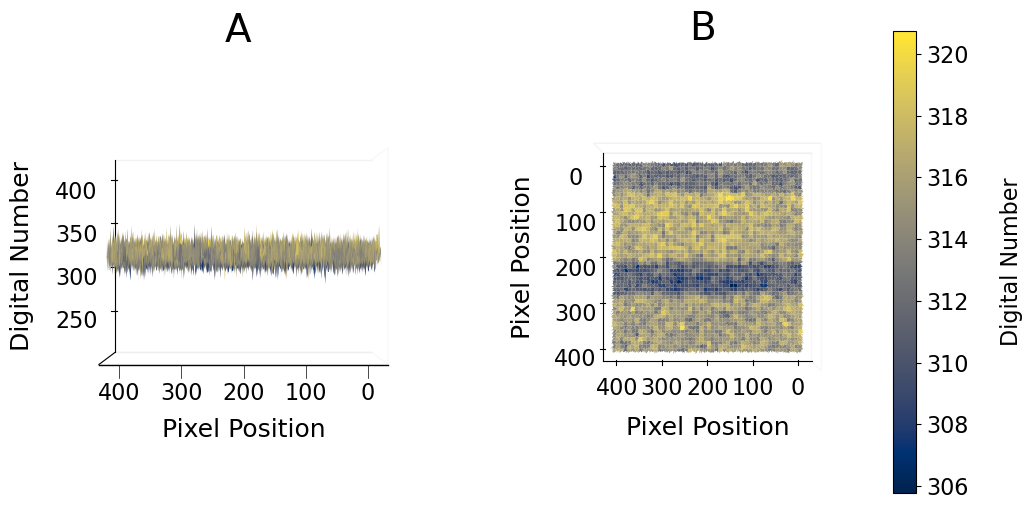

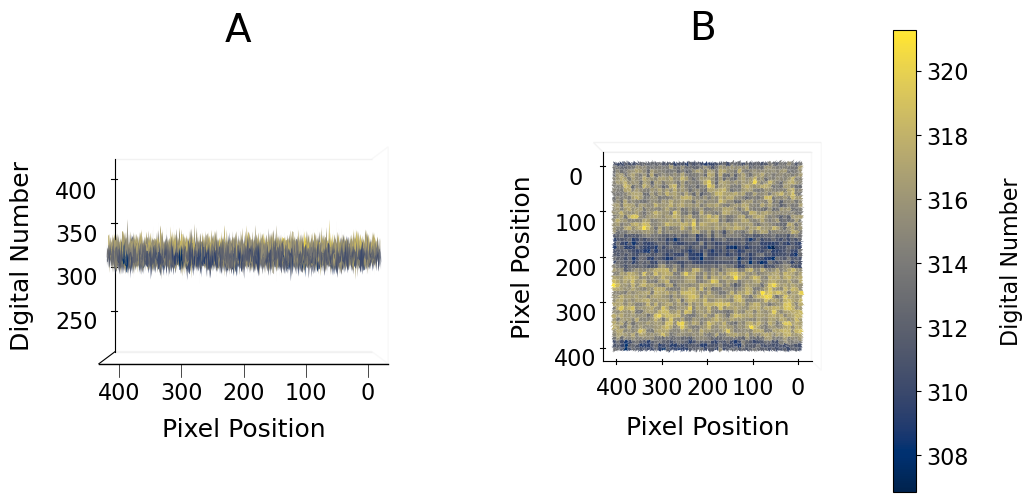

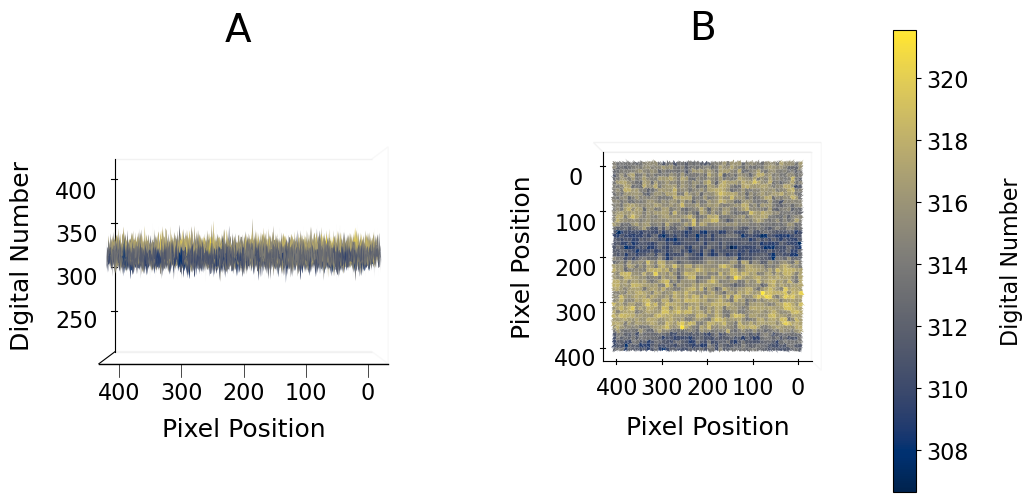

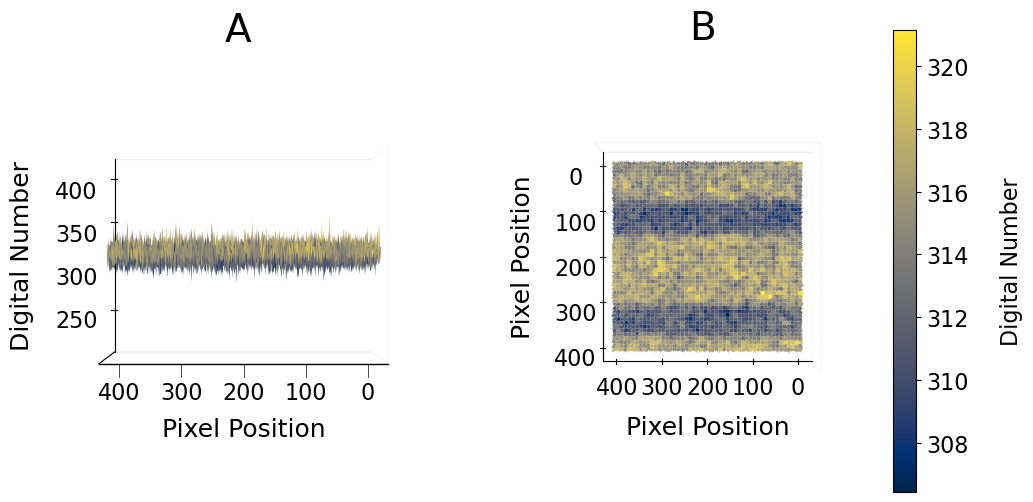

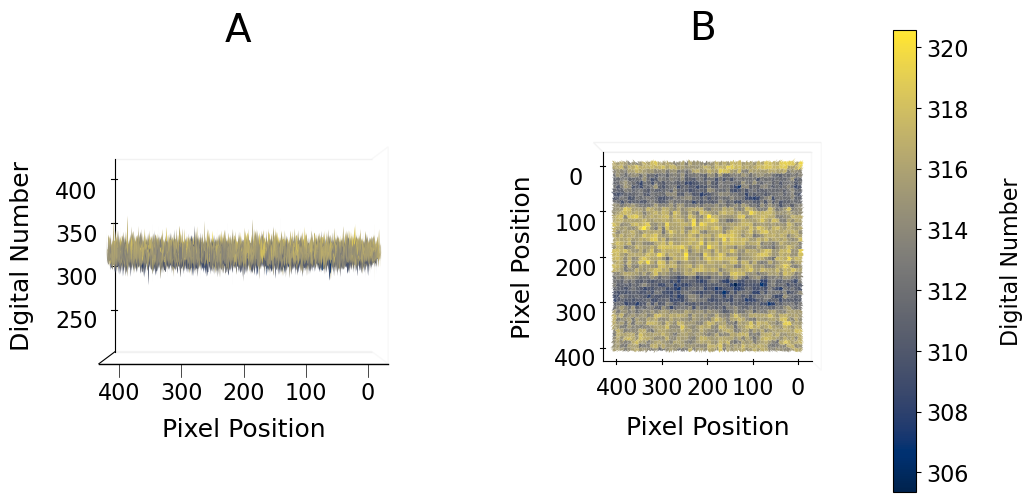

In [17]:
# Build ROI stack: (N, H, W)
roi_stack = green_arr[:, y1:y1+wy1, x1:x1+wx1]
N, H, W = roi_stack.shape

A, xx, yy = precompute_quadratic_design(H, W)

flat_stack = np.empty_like(roi_stack, dtype=np.float64)
resid_stack = np.empty_like(roi_stack, dtype=np.float64)

for i in range(N):
    curv_field, resid, flat = flatten_frame_quadratic(roi_stack[i], A)
    resid_stack[i] = resid
    flat_stack[i] = flat

    # optional: save a plot per frame
    flat_field.flat_field(flat, 'A', 'B', f'uncurved_{i}.png')


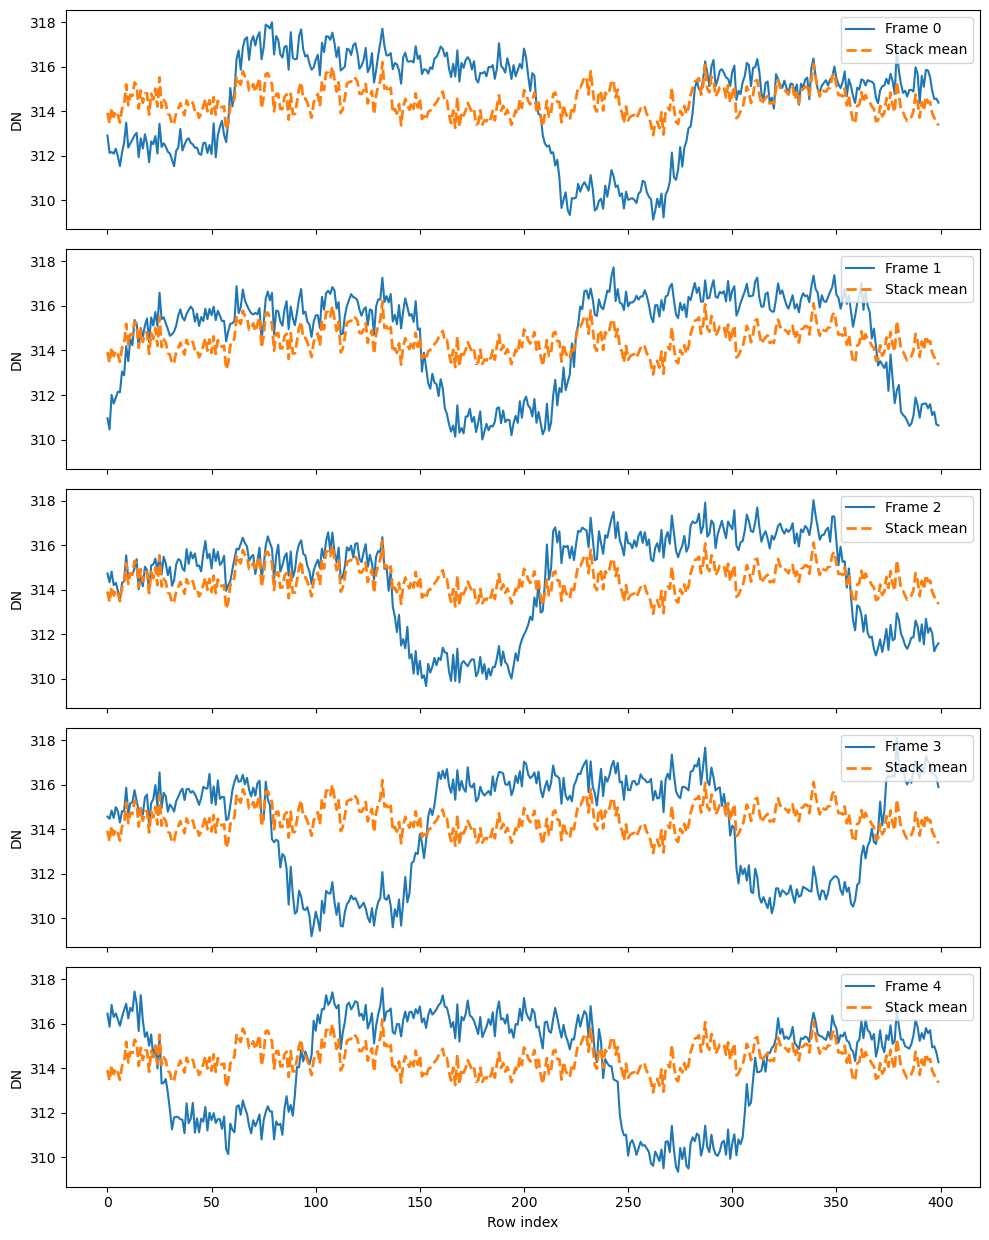

In [18]:
# Choose which data to profile
data = flat_stack   # or resid_stack if you want zero-mean residuals

# Row profiles: mean across columns
profiles = data.mean(axis=2)   # shape (N, H)

# Optional stacked profile
stack_profile = profiles.mean(axis=0)

N, H = profiles.shape

fig, axes = plt.subplots(N, 1, figsize=(10, 2.5 * N), sharex=True, sharey=True)

for i in range(N):
    axes[i].plot(profiles[i], label=f'Frame {i}')
    axes[i].plot(stack_profile, '--', linewidth=2, label='Stack mean')
    axes[i].legend(loc='upper right')
    axes[i].set_ylabel('DN')

axes[-1].set_xlabel('Row index')
plt.tight_layout()
plt.show()



In [19]:
def row_profile(img2d):
    """Mean across columns -> one value per row."""
    return img2d.mean(axis=1)

def rms_detrended(x):
    """RMS after removing the mean (row ripple RMS)."""
    x = np.asarray(x, dtype=np.float64)
    x = x - x.mean()
    return np.sqrt(np.mean(x**2))

def rolling_window_rms(x, L):
    """
    RMS (after local mean removal) computed for every contiguous window of length L.
    Returns array of length len(x)-L+1.
    """
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    if L > n:
        raise ValueError(f"L={L} larger than signal length n={n}")

    out = np.empty(n - L + 1, dtype=np.float64)
    for i in range(n - L + 1):
        w = x[i:i+L]
        w = w - w.mean()
        out[i] = np.sqrt(np.mean(w**2))
    return out

def find_quiet_window(profile, L=100):
    """
    Find the contiguous row window of length L with the smallest local RMS ripple.
    Returns (start_idx, end_idx_exclusive, quiet_rms).
    """
    rms_vals = rolling_window_rms(profile, L)
    i0 = int(np.argmin(rms_vals))
    return i0, i0 + L, float(rms_vals[i0])


In [20]:
# Choose which stack you want to analyze:
# data_stack = flat_stack
data_stack = flat_stack   # or resid_stack

N, H, W = data_stack.shape

# Per-frame row profiles
profiles = np.vstack([row_profile(data_stack[i]) for i in range(N)])  # (N, H)

# Stacked profile (mean of frames)
stack_profile = profiles.mean(axis=0)

# --- Original analysis metric (your current method) ---
sigma_stack_total = rms_detrended(stack_profile)

# --- New method: "floating quiet window" noise floor ---
L = 100
quiet_windows = []
quiet_rms_each = []

for i in range(N):
    i0, i1, q_rms = find_quiet_window(profiles[i], L=L)
    quiet_windows.append((i0, i1))
    quiet_rms_each.append(q_rms)

quiet_rms_each = np.array(quiet_rms_each)
sigma_quiet = quiet_rms_each.mean()  # overall noise-floor estimate

# --- Estimate banding contribution in stacked profile by quadrature ---
sigma_band_est = np.sqrt(max(0.0, sigma_stack_total**2 - sigma_quiet**2))

print(f"Original stacked-profile RMS (total residual): {sigma_stack_total:.4f} DN")
print(f"Quiet-window RMS (noise floor), per frame:     {quiet_rms_each}")
print(f"Quiet-window RMS (mean noise floor):            {sigma_quiet:.4f} DN")
print(f"Estimated banding RMS via quadrature:           {sigma_band_est:.4f} DN")


Original stacked-profile RMS (total residual): 0.6281 DN
Quiet-window RMS (noise floor), per frame:     [0.49276082 0.43220089 0.52712689 0.47807116 0.50108518]
Quiet-window RMS (mean noise floor):            0.4862 DN
Estimated banding RMS via quadrature:           0.3976 DN


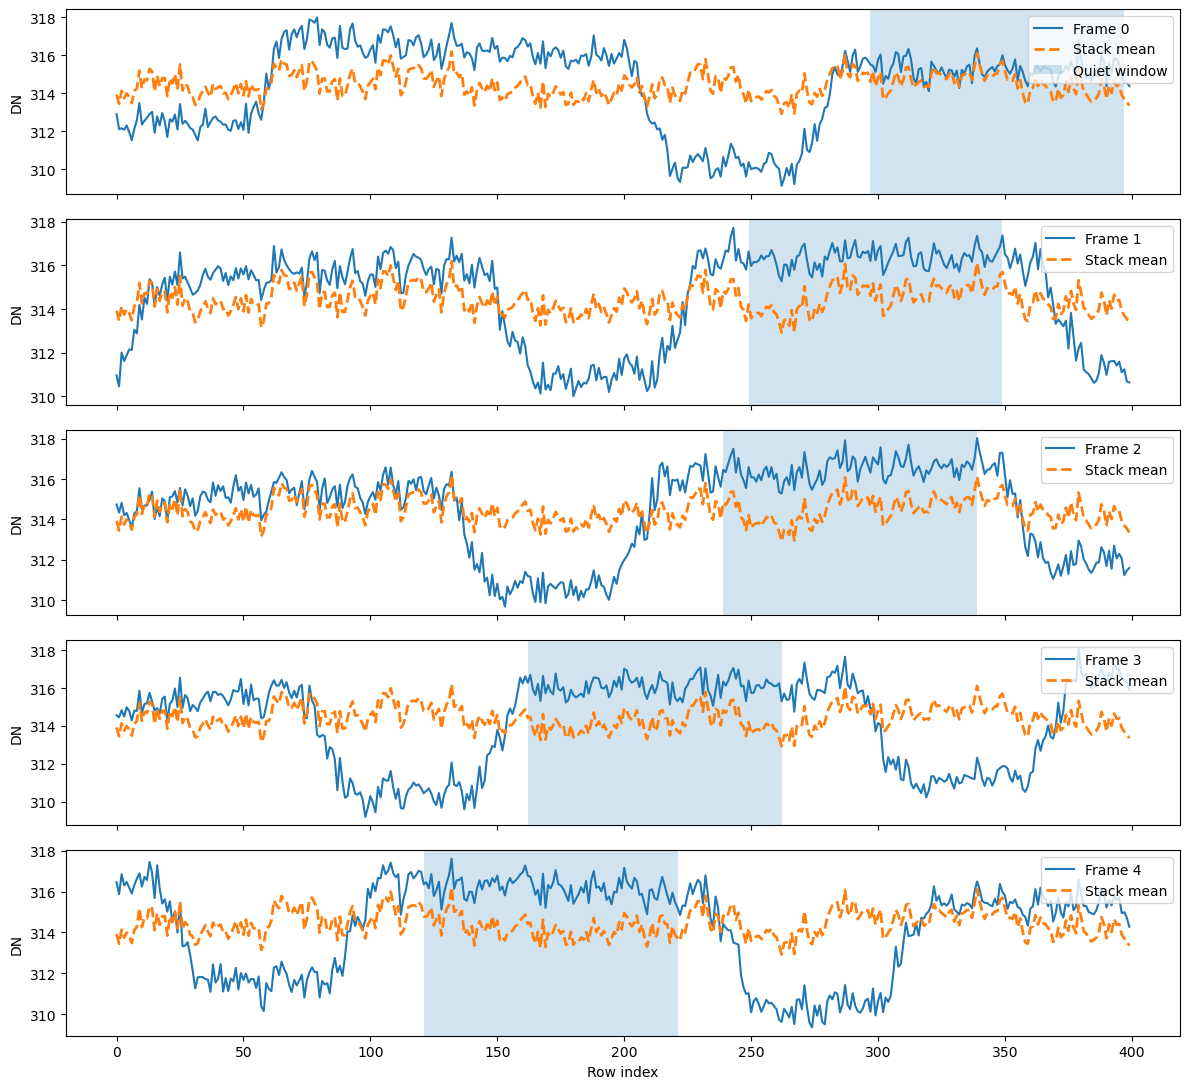

In [21]:
fig, axes = plt.subplots(N, 1, figsize=(12, 2.2*N), sharex=True)

for i in range(N):
    ax = axes[i]
    ax.plot(profiles[i], label=f'Frame {i}')
    ax.plot(stack_profile, '--', linewidth=2, label='Stack mean')

    i0, i1 = quiet_windows[i]
    ax.axvspan(i0, i1, alpha=0.2, label='Quiet window' if i == 0 else None)

    ax.set_ylabel("DN")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Row index")
plt.tight_layout()
plt.show()
